# Đề tài: Phân tích hiệu quả kinh doanh và xây dựng mô hình dự báo doanh thu cho chuỗi siêu thị đa chi nhánh tại Myanmar

## Data Dictionary:
- Invoice ID – Unique identifier for each transaction/invoice.
- Branch – Branch code of the supermarket (e.g., A, B, C).
- City – City where the supermarket branch is located.
- Customer type – Type of customer (e.g., Member, Normal).
- Gender – Gender of the customer.
- Product line – Product category (e.g., Health and beauty, Electronic - accessories, Food and beverages).
- Unit price – Price of a single product unit.
- Quantity – Number of product units purchased.
- Tax 5% – 5% tax amount applied to the purchase.
- Total – Total price including tax.
- Date – Date of purchase.
- Time – Time of purchase.
- Payment – Payment method (e.g., Cash, Credit card, Ewallet).
- cogs – Cost of goods sold (before tax).
- gross margin percentage – Gross margin percentage for the transaction.
- gross income – Profit earned from the transaction (cogs × margin).
- Rating – Customer satisfaction rating (typically 1–10).

## Tiếng Việt:
- Invoice ID – Mã định danh duy nhất cho mỗi giao dịch/hóa đơn.
- Branch – Mã chi nhánh của siêu thị (ví dụ: A, B, C).
- City – Thành phố nơi chi nhánh siêu thị tọa lạc.
- Customer type – Loại khách hàng (ví dụ: Thành viên, Khách hàng thông thường).
- Gender – Giới tính của khách hàng.
- Product line – Danh mục sản phẩm (ví dụ: Sức khỏe và sắc đẹp, Điện tử - phụ kiện, Thực phẩm và đồ uống).
- Unit price – Giá của một đơn vị sản phẩm.
- Quantity – Số lượng đơn vị sản phẩm đã mua.
- Tax 5% – Thuế suất 5% áp dụng cho giao dịch mua.
- Total – Tổng giá bao gồm thuế.
- Date – Ngày mua hàng.
- Time – Giờ mua hàng.
- Payment – Phương thức thanh toán (ví dụ: Tiền mặt, Thẻ tín dụng, Ví điện tử).
- cogs – Giá vốn hàng bán (trước thuế).
- gross margin percentage – Tỷ lệ lợi nhuận gộp của giao dịch. 
- gross income – Lợi nhuận thu được từ giao dịch (giá vốn hàng bán × tỷ suất lợi nhuận).
- Rating – Mức độ hài lòng của khách hàng (thường từ 1–10).

# Import thư viện và Đọc dữ liệu

In [2]:
# Cài đặt thư viện xử
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tiền xử lý dữ liệu
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Mô hình Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Đánh giá mô hình
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
path = './data/Supermarket_sales.csv'
alpha = 0.5

df = pd.read_csv(path)

In [4]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


# Data Preparation / Data Preprocessing / EDA

## Data Understanding (Thấu hiểu dữ liệu)

In [6]:
df.shape

# Data có 1000 dòng và 17 cột

(1000, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [8]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [9]:
df.describe(include='object')

,Invoice ID,Branch,City,Customer type,Gender,Product line,Date,Time,Payment
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,2,2,6,89,506,3
top,750-67-8428,A,Yangon,Member,Female,Fashion accessories,2/7/2019,19:48,Ewallet
freq,1,340,340,501,501,178,20,7,345


In [10]:
df.nunique()

# Có 3 branch: A, B, C
# Ở 3 thành phố: Yangon, Mandalay, Naypyitaw
# 2 loại khách hàng: Member và Normal
# 6 Produt line: Fashion accessories, Food and beverages, Electronic accessories, Sports and travel, Home and lifestyle, Health and beauty
# 3 loại thanh toán: Cash, Credit card, Ewallet

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Total                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

## Data Cleaning (Dọn dẹp dữ liệu)

In [11]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.dtypes

# Date và Time đang ở dạng object, cần chuyển về datetime
# Branch, City, Customer type, Gender, Product line, và Payment đang ở dạng object, cần chuyển về category

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [14]:
# 1. Chuyển đổi ngày tháng
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time']).dt.time # Hoặc giữ nguyên datetime tùy mục đích

# 2. Chuyển đổi các cột phân loại
category_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in category_cols:
    df[col] = df[col].astype('category')
    
df.dtypes

C:\Users\ngong\AppData\Local\Temp\ipykernel_7424\2477708677.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time']).dt.time # Hoặc giữ nguyên datetime tùy mục đích


Invoice ID                         object
Branch                           category
City                             category
Customer type                    category
Gender                           category
Product line                     category
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                          category
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [15]:
quantCols = ['Unit price', 'Tax 5%', 'Quantity', 'Total']

# Kiểm tra xem có giá trị âm không
negCounts = (df[quantCols] < 0).sum()
negCounts

#không có giá trị âm ở các cột số lượng

Unit price    0
Tax 5%        0
Quantity      0
Total         0
dtype: int64

## Univariate Analysis (Phân tích đơn biến)

In [16]:
df.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6


### Branch & City

C:\Users\ngong\AppData\Local\Temp\ipykernel_7424\3954065542.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels)


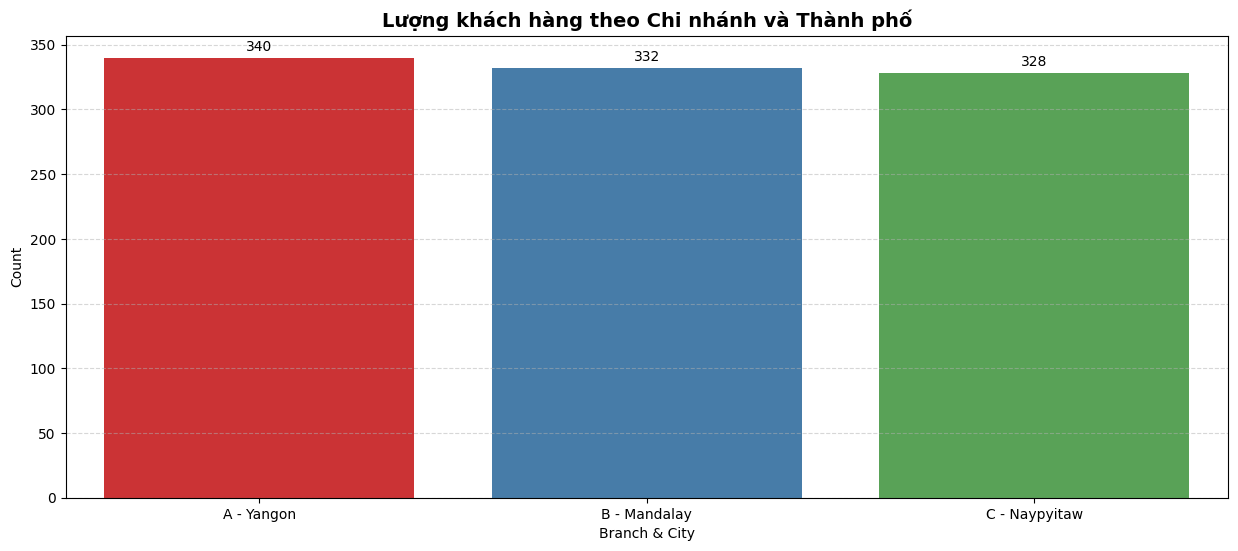

In [49]:
plt.figure(figsize=(15, 6))
ax = sns.countplot(x='Branch', hue='Branch', data=df, palette='Set1')
custom_labels = ['A - Yangon', 'B - Mandalay', 'C - Naypyitaw']
ax.set_xticklabels(custom_labels)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Lượng khách hàng theo Chi nhánh và Thành phố', fontsize=14, fontweight='bold')
plt.xlabel('Branch & City')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=alpha)

plt.show()

**Nhận xét:** Biểu đồ cho thấy sự cân bằng về số lượng khách hàng tại 3 thành phố lớn.

**Số liệu:**
- **Yangon (A)** dẫn đầu với 340 lượt khách.
- **Naypyitaw (C) và Mandalay (B)** bám sát với lần lượt 328 và 332 lượt khách.

### Customer type & Gender

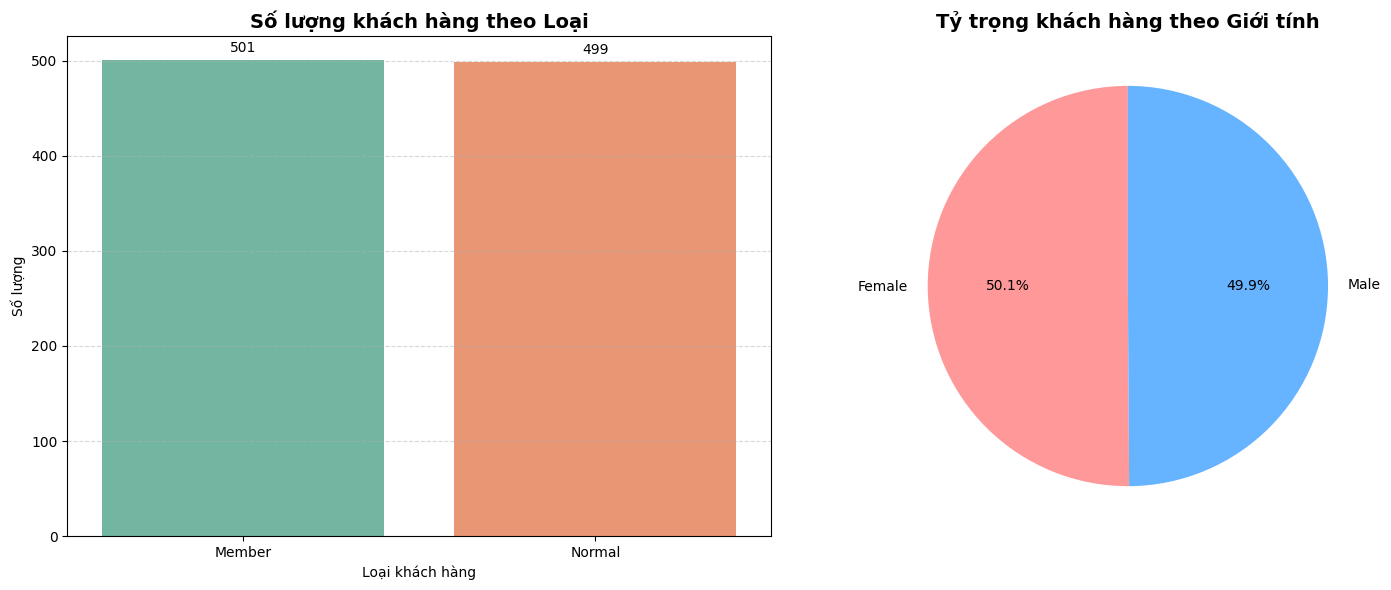

In [50]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=df, x='Customer type', hue='Customer type', palette='Set2')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3)
plt.title('Số lượng khách hàng theo Loại', fontsize=14, fontweight='bold')
plt.xlabel('Loại khách hàng')
plt.ylabel('Số lượng')
plt.grid(axis='y', linestyle='--', alpha=alpha)


# Gender
gender_counts = df['Gender'].value_counts()
plt.subplot(1, 2, 2)
plt.pie(gender_counts, 
        labels = gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#ff9999','#66b3ff'],
        )

plt.title('Tỷ trọng khách hàng theo Giới tính', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** Cả hai biểu đồ đều cho thấy một sự cân bằng tuyệt đối trong tập dữ liệu. Doanh nghiệp đang phục vụ một lượng khách hàng cực kỳ đa dạng và không bị lệch về bất kỳ nhóm đối tượng cụ thể nào.

**Biểu đồ 1: Phân bổ theo Loại khách hàng (Customer type)**
- Số liệu: Nhóm khách hàng Member (Thành viên) và Normal (Khách lẻ) có số lượng gần như bằng nhau, đạt mức xấp xỉ 500 khách hàng cho mỗi nhóm.
- Ý nghĩa: Tỷ lệ chuyển đổi khách hàng vãng lai sang khách hàng thân thiết đang ở mức 50%. Đây là một chỉ số khá tốt, cho thấy các chính sách thành viên có sức hút nhưng vẫn còn dư địa 50% khách hàng lẻ để tiếp tục khai thác.

**Biểu đồ 2: Phân bổ theo Giới tính (Gender)**
- Số liệu: Tương tự, số lượng khách hàng Nam (Male) và Nữ (Female) cũng dao động quanh mức 500 người.
- Ý nghĩa: Sản phẩm hoặc dịch vụ của doanh nghiệp mang tính đại chúng cao (Unisex). Không có sự phân biệt về nhu cầu giữa nam và nữ trong việc tiêu dùng tại các chi nhánh.

### Product line

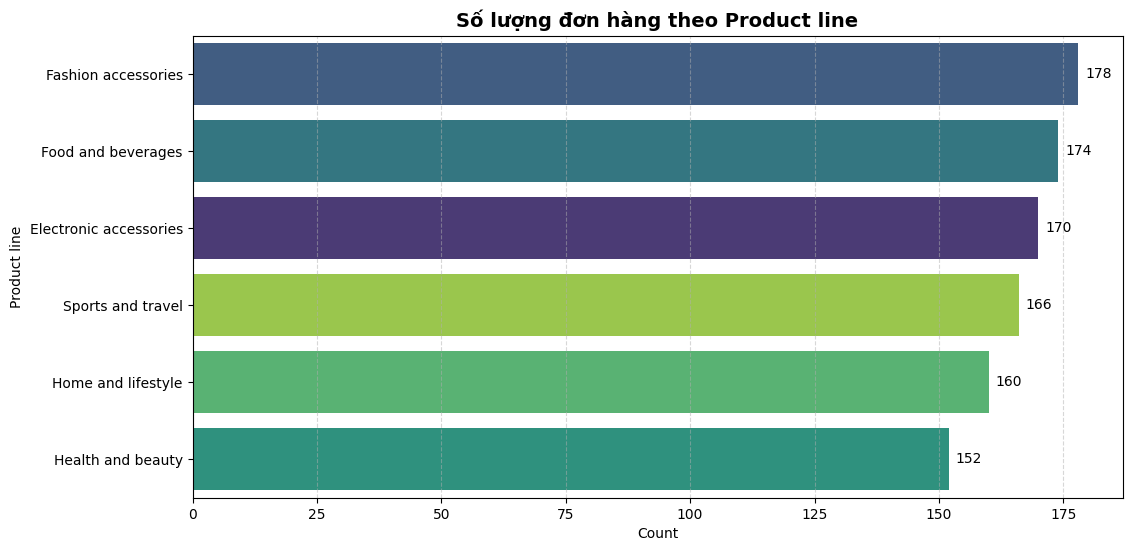

In [19]:
product_counts = df['Product line'].value_counts().reset_index()
product_counts.columns = ['Product line', 'Count']

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='Count', 
    y='Product line',
    hue = 'Product line',
    data=product_counts, 
    palette='viridis',
    order=product_counts['Product line']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

plt.grid(axis='x', linestyle='--', alpha=alpha)

plt.title('Số lượng đơn hàng theo Product line', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Product line')

plt.show()

**Nhận xét:** Biểu đồ thể hiện số lượng đơn hàng của 6 dòng sản phẩm chính tại siêu thị. Nhìn chung, sự chênh lệch giữa dòng sản phẩm bán chạy nhất và bán chậm nhất là không quá lớn (khoảng 10-20 đơn hàng), cho thấy một danh mục sản phẩm có sức mua rất ổn định và đồng đều.

**Phân tích chi tiết:**
- Fashion accessories (Phụ kiện thời trang): Đang chiếm ưu thế với số lượng đơn hàng cao nhất. Điều này cho thấy khách hàng có xu hướng mua sắm các mặt hàng nhỏ lẻ, mang tính thẩm mỹ cao khi ghé thăm siêu thị.
- Food and beverages (Thực phẩm & Đồ uống): Xếp ngay sau đó, khẳng định đây là nhóm nhu yếu phẩm đóng vai trò "giữ chân" khách hàng thường xuyên.
- Health and beauty (Sức khỏe & Làm đẹp): Dù đứng cuối danh sách, nhưng con số này vẫn đạt mức khá cao (trên 150 đơn), chứng tỏ tiềm năng khai thác của nhóm ngành này vẫn còn rất lớn.

### Unit price

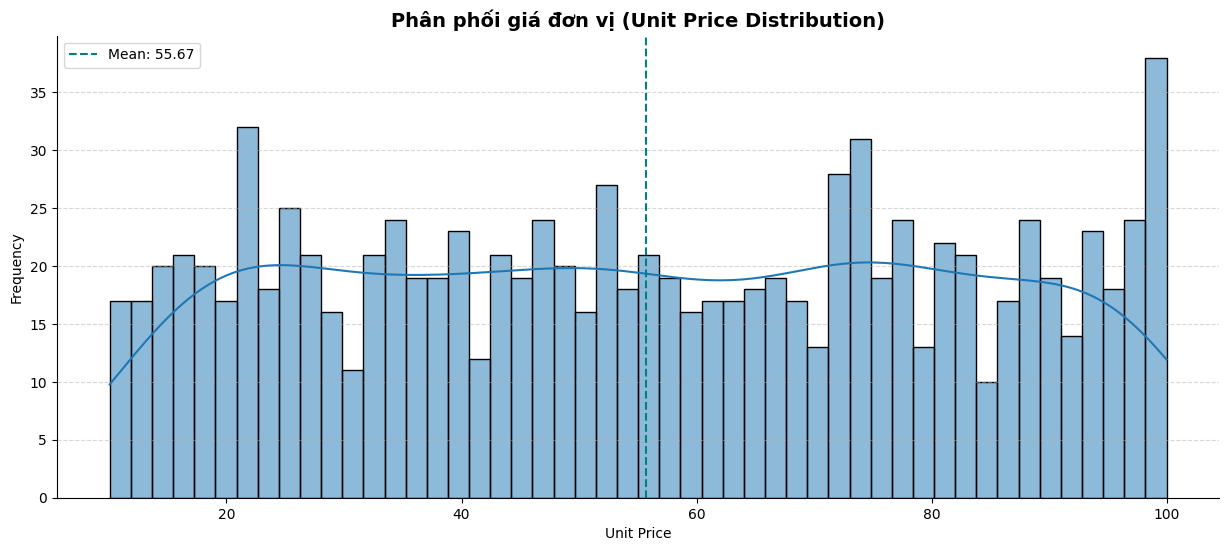

In [20]:
plt.figure(figsize=(15, 6))

sns.histplot(df['Unit price'], kde=True, bins=50)

plt.axvline(df['Unit price'].mean(), color='teal', linestyle='--', label=f'Mean: {df['Unit price'].mean():.2f}')
plt.title('Phân phối giá đơn vị (Unit Price Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=alpha)

sns.despine()
plt.show()

**Nhận xét:** Biểu đồ Histogram nhìn chung có phân phối trải dài, nhưng xuất hiện các đỉnh nhọn cục bộ (Local Peaks). Điều này cho thấy lượng khách hàng không hoàn toàn đồng đều ở toàn bộ mức giá mà tập trung vào một số khung giá cụ thể.

**Phân tích chi tiết:**
- Đỉnh cao nhất tại vùng giá 100: Cột Histogram tại sát mốc quanh 100 có tần suất cao nhất, chứng tỏ một lượng lớn sản phẩm trong danh mục của cửa hàng là hàng cao cấp hoặc các mặt hàng có mức giá tối đa trong phân khúc.
- Vùng giá thấp (10 - 30): Cũng ghi nhận một đỉnh nhọn khác, cho thấy các sản phẩm, nhu yếu phẩm giá rẻ cũng thu hút một lượng giao dịch lớn.

### Payment

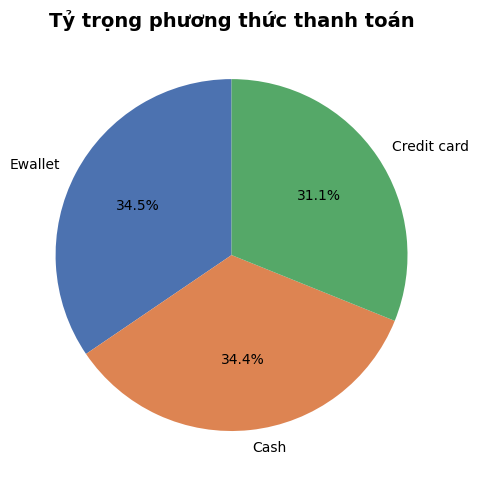

In [21]:
payment_counts = df['Payment'].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('deep', 3))
plt.title('Tỷ trọng phương thức thanh toán', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ cho thấy sự phân bổ cực kỳ đồng đều giữa ba loại hình thanh toán. Sự chênh lệch giữa phương thức được sử dụng nhiều nhất và ít nhất là rất nhỏ, cho thấy khách hàng của siêu thị có thói quen thanh toán đa dạng và linh hoạt.

**Phân tích chi tiết:**
- E-wallet (Ví điện tử): Đang dẫn đầu với tỉ trọng 34.5%, chứng tỏ nhóm khách hàng của siêu thị khá hiện đại và ưu tiên các giải pháp thanh toán công nghệ, tiện lợi.
- Cash (Tiền mặt): Xếp thứ hai với 34.4% giao dịch, cho thấy tiền mặt vẫn giữ một vai trò cực kỳ quan trọng và chưa thể thay thế trong thói quen tiêu dùng hàng ngày.
- Credit card (Thẻ tín dụng): Đứng cuối với lượng giao dịch chiếm 31.1% tỉ trọng. Dù thấp hơn hai loại hình còn lại nhưng con số này vẫn ở mức cao, đóng góp đáng kể vào doanh số.

### Rating

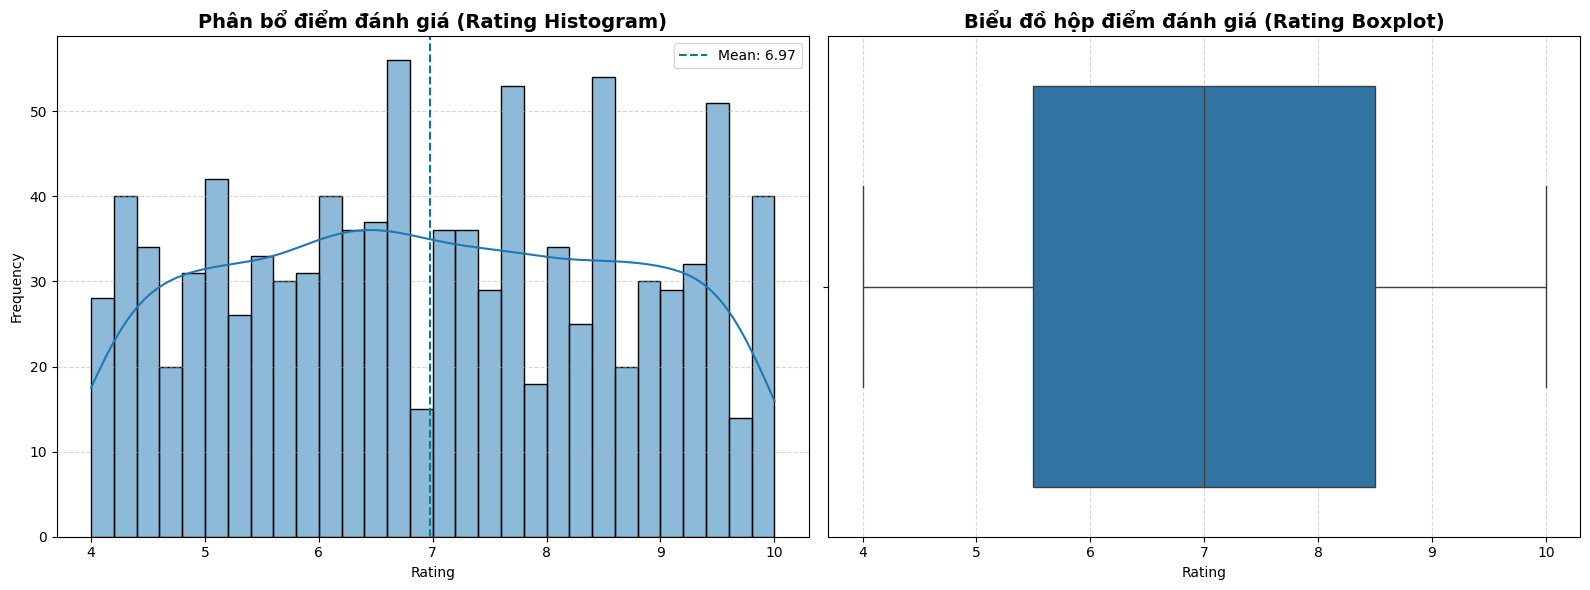

In [51]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Rating'], kde=True, bins=30)
plt.axvline(df['Rating'].mean(), color='teal', linestyle='--', label=f"Mean: {df['Rating'].mean():.2f}")
plt.title('Phân bổ điểm đánh giá (Rating Histogram)', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=alpha)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Rating'])
plt.title('Biểu đồ hộp điểm đánh giá (Rating Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.grid(axis='x', linestyle='--', alpha=alpha)

plt.tight_layout()
plt.show()

**Phân tích Histogram:**
- Phân bổ đa đỉnh (Multimodal Distribution): Biểu đồ không tập trung vào một điểm duy nhất mà có nhiều đỉnh nhỏ rải rác từ mức 4.0 đến 10.0. Điều này cho thấy ý kiến của khách hàng về chất lượng dịch vụ rất đa dạng, không có sự đồng thuận tuyệt đối ở một mức điểm nào.
- Tính đối xứng: Đường trung bình (Mean: 6.97) nằm gần như chính giữa dải điểm. Đường KDE khá phẳng ở đỉnh, xác nhận rằng mức độ hài lòng trung bình của khách hàng đang duy trì ổn định ở mức khá (xấp xỉ 7/10).

**Phân tích Boxplot:**
- Khoảng giá trị phổ biến (IQR): 50% lượng khách hàng đánh giá tập trung trong khoảng từ 5.5 đến 8.5. Đây là một "vùng an toàn" khá rộng, cho thấy siêu thị hiếm khi nhận được những đánh giá quá tệ nhưng cũng chưa thực sự bứt phá lên mức xuất sắc.
- Giá trị trung vị (Median): Đường gạch dọc trong hộp nằm ở mức 7.0, khớp với giá trị trung bình, cho thấy dữ liệu không bị nhiễu bởi các giá trị cực đoan.
- Ngoại lai (Outliers): Tuyệt đối không có điểm ngoại lai (Outliers). Điều này rất quan trọng trong quản trị dịch vụ, chứng tỏ không có trường hợp khách hàng nào phản ứng cực đoan (như chấm 1-2 điểm) gây ảnh hưởng đến uy tín hệ thống.

## Bivariate Analysis (Phân tích hai biến)

In [44]:
df.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6


### Total - Product line

C:\Users\ngong\AppData\Local\Temp\ipykernel_7424\2946236322.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_by_product = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).reset_index()


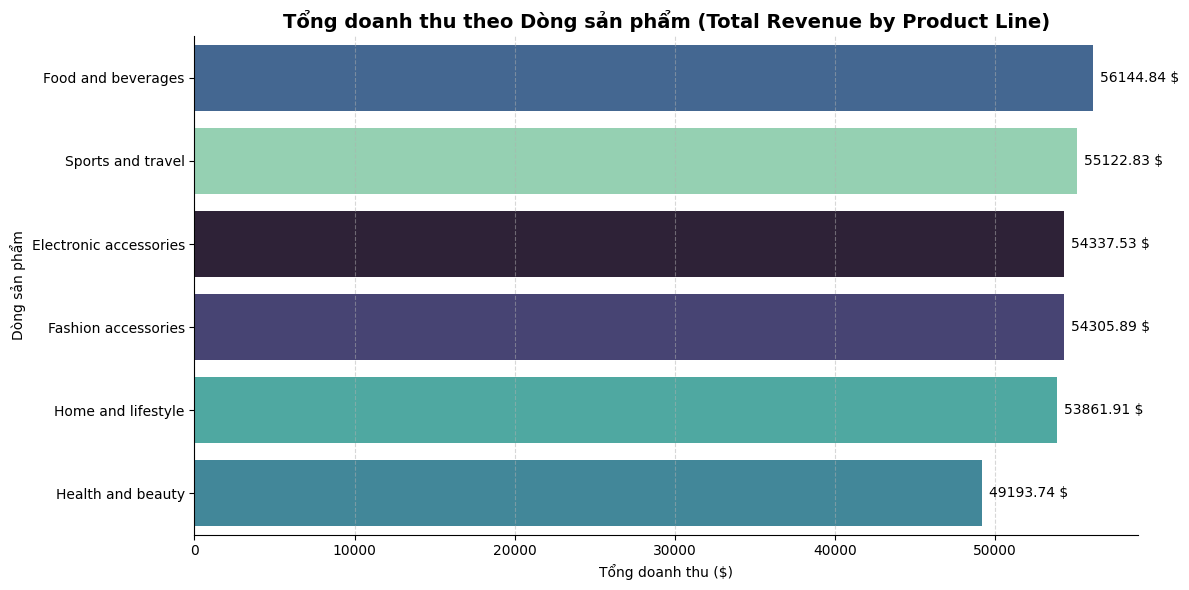

In [39]:
total_by_product = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=total_by_product, 
    x='Total', 
    y='Product line',
    hue = 'Product line',
    palette='mako',
	order=total_by_product['Product line']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f $', padding=5)

plt.title('Tổng doanh thu theo Dòng sản phẩm (Total Revenue by Product Line)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng doanh thu ($)')
plt.ylabel('Dòng sản phẩm')
plt.grid(axis='x', linestyle='--', alpha=alpha)

sns.despine(right=True, top=True)
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ cho thấy tổng doanh thu từ 6 dòng sản phẩm dao động trong khoảng từ 49,000$ đến 57,000$. Sự chênh lệch giữa dòng cao nhất và thấp nhất là khoảng 12.4%. Đây là một chỉ số cho thấy cơ cấu doanh thu của cửa hàng rất bền vững vì không bị phụ thuộc quá lớn vào một nhóm hàng duy nhất.

**Phân tích chi tiết:**
- Doanh thu cao nhất - Food and beverages (56,144$): Đây là dòng sản phẩm mang lại dòng tiền lớn nhất. Dù Fashion accessories có số lượng đơn hàng cao hơn, nhưng về giá trị thực thu, thực phẩm và đồ uống mới là nguồn thu chính của chuỗi doanh nghiệp.
- Các nhóm khác: Sports and travel (55,122$), Electronic accessories (54,337$) và Fashion accessories (54,305$) có mức doanh thu gần như tương đương nhau, tạo thành nhóm "trụ cột" doanh số thứ hai.
- Doanh thu thấp nhất: Home and lifestyle (53,861$) và Health and beauty (49,193$): 2 dòng sản phẩm này đứng cuối ở cả số lượng đơn hàng lẫn tổng doanh thu.

**Insight:**
- Dòng Sports and travel tuy không dẫn đầu về số đơn nhưng lại đứng thứ 2 về doanh thu, chứng tỏ khách hàng thường mua các món đồ có giá trị cao ở danh mục này => Sports and travel có giá trị đơn hàng trung bình (AOV) cao
- Ngược lại, Fashion accessories tuy dẫn đầu về số lượng đơn (178 đơn) nhưng chỉ đứng thứ 4 về doanh thu. Điều này cho thấy khách hàng mua phụ kiện thời trang rất thường xuyên nhưng giá trị mỗi món đồ lại thấp => Fashion accessories có giá trị đơn hàng trung bình (AOV) thấp

**Đề xuất:**
- Tối ưu hóa lợi nhuận: Vì Food and beverages đang dẫn đầu doanh thu, siêu thị nên kiểm tra lại gross income của dòng này. Nếu biên lợi nhuận tốt, hãy mở rộng diện tích quầy kệ cho nhóm này để tăng tiếp cận khách hàng.
- Chiến lược cho nhóm Health & Beauty: Doanh thu dưới mức 50,000 $ cho thấy đây là nhóm cần được kích cầu. Có thể áp dụng chiến thuật "bundle sales" (bán kèm) với nhóm Fashion để tận dụng lượng khách mua phụ kiện đông đảo.
- Sắp xếp kho bãi: Nhóm Sports and travel mang lại doanh thu cao thứ 2, nên được bố trí ở những vị trí khách dễ tiếp cận nhất để thúc đẩy các đơn hàng giá trị lớn.

### Rating - Branch

C:\Users\ngong\AppData\Local\Temp\ipykernel_7424\3015138807.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels)


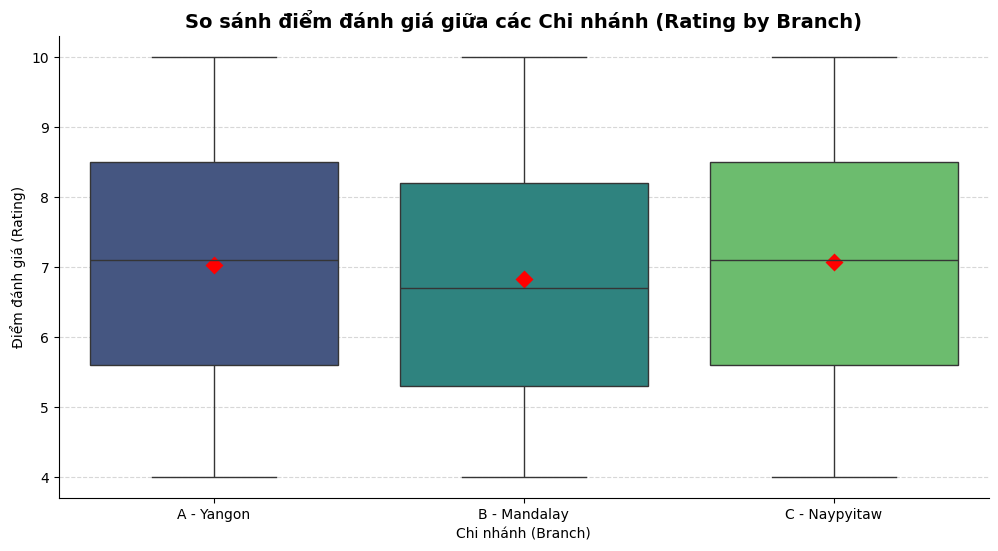

In [43]:
plt.figure(figsize=(12, 6))

ax = sns.boxplot(data=df, x='Branch', y='Rating', hue='Branch', palette='viridis', order=['A', 'B', 'C'])
ax.set_xticklabels(custom_labels)

sns.pointplot(data=df, x='Branch', y='Rating', color='red', markers='D', linestyles='', errorbar=None)

plt.title('So sánh điểm đánh giá giữa các Chi nhánh (Rating by Branch)', fontsize=14, fontweight='bold')
plt.xlabel('Chi nhánh (Branch)')
plt.ylabel('Điểm đánh giá (Rating)')

plt.grid(axis='y', linestyle='--', alpha=alpha)

sns.despine()
plt.show()

**Nhận xét:** Mức độ hài lòng của khách hàng tại 3 thành phố lớn (Yangon, Mandalay, Naypyitaw) có sự đồng nhất rất cao. Cả 3 chi nhánh đều duy trì mức điểm đánh giá trung bình quanh ngưỡng 7.0/10.0. Điều này chứng tỏ quy trình quản lý chất lượng dịch vụ của siêu thị đang được thực hiện tốt và đồng bộ trên toàn quốc.

**Phân tích chi tiết:**
- Chi nhánh A (Yangon) & C (Naypyitaw): Hai chi nhánh này có hiệu suất gần như tương đương. Điểm trung bình (điểm đỏ) và trung vị (đường gạch ngang) đều nằm ở mức ~7.1. Đây là hai khu vực có mức độ hài lòng ổn định nhất.
- Chi nhánh B (Mandalay): Có một chút khác biệt nhẹ. Điểm trung vị của chi nhánh này thấp hơn hai chi nhánh còn lại (nằm dưới mức 7.0). Tuy nhiên, điểm trung bình (điểm đỏ) vẫn đạt xấp xỉ 6.8, cho thấy dù có một nhóm khách hàng đánh giá hơi thấp nhưng nhìn chung vẫn nằm trong tầm kiểm soát.

**Đặc điểm phân tán (Box & Whiskers):**
- Khoảng biến thiên (Range): Cả 3 chi nhánh đều nhận mức điểm trải dài từ 4.0 đến 10.0. Không có chi nhánh nào xuất hiện điểm ngoại lai (outliers), nghĩa là không có trường hợp khách hàng nào phản ứng quá tiêu cực một cách bất thường.
- Độ tập trung (IQR): 50% khách hàng tại chi nhánh A và C tập trung đánh giá trong khoảng từ 5.6 đến 8.5. Tại chi nhánh B, hộp (box) có vẻ thấp hơn một chút, cho thấy khách hàng ở Mandalay có phần không hài lòng hơn đôi chút so với hai thành phố kia.

**Insight & Đề xuất:**
- Duy trì tiêu chuẩn: Siêu thị nên tiếp tục duy trì các tiêu chuẩn phục vụ hiện tại vì mức điểm 7.0 là mức khá tốt trong ngành bán lẻ.
- Tối ưu chi nhánh B: Quản lý tại Mandalay (Chi nhánh B) nên xem xét lại các phản hồi cụ thể để hiểu tại sao điểm trung vị lại thấp hơn một chút so với Yangon và Naypyitaw. Có thể do đặc thù văn hóa tiêu dùng hoặc dịch vụ tại đây cần được tinh chỉnh thêm.
- Chiến lược nâng hạng: Để đưa điểm số từ 7.0 lên 8.5, siêu thị có thể triển khai các chương trình chăm sóc khách hàng đặc biệt cho nhóm khách hàng Member tại chi nhánh C (Naypyitaw) vì đây là nơi có tiềm năng bứt phá điểm số cao nhất.

### Quantity - Customer type

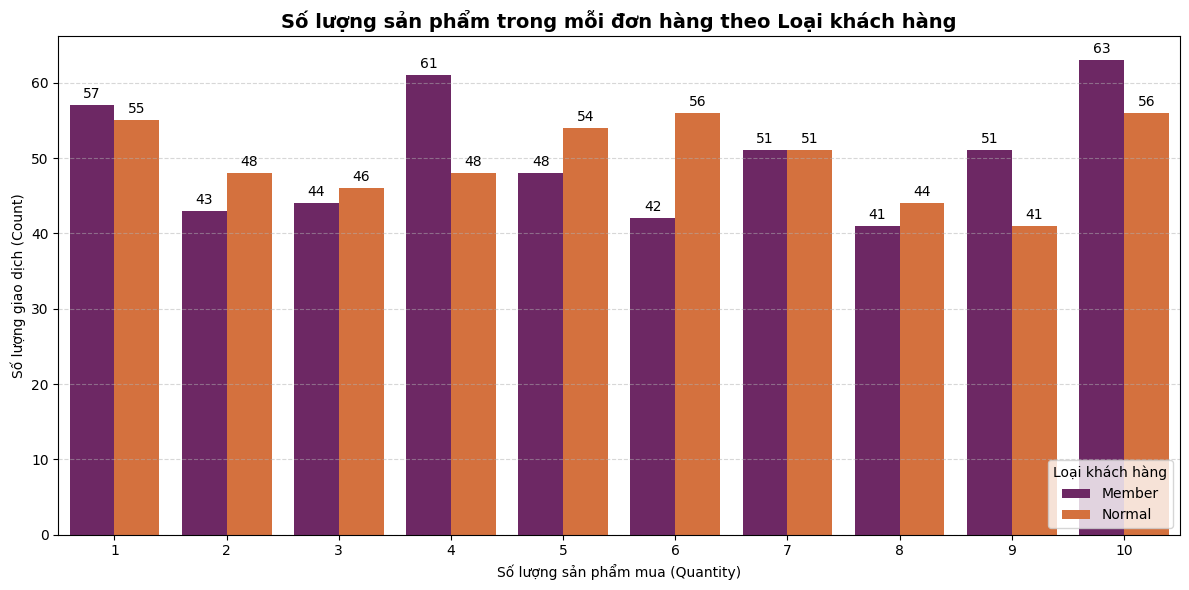

In [76]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df, x='Quantity', hue='Customer type', palette='inferno')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Số lượng sản phẩm trong mỗi đơn hàng theo Loại khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng sản phẩm mua (Quantity)')
plt.ylabel('Số lượng giao dịch (Count)')
plt.legend(title='Loại khách hàng', loc='lower right')

plt.grid(axis='y', linestyle='--', alpha=alpha)
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ cho thấy một sự phân bổ khá thú vị: khách hàng không chỉ mua lẻ 1-2 món mà có xu hướng mua sắm với số lượng lớn (7-10 món) rất thường xuyên. Đặc biệt, nhóm khách hàng Thành viên (Member) có những điểm bứt phá rõ rệt ở hai mốc 4 và 10 món.

**Phân tích chi tiết:**
- Nhóm mua sắm tối đa (Quantity 10): Đây là mốc có số lượng giao dịch cao nhất toàn biểu đồ. Khách hàng Member dẫn đầu với 63 giao dịch, cho thấy nhóm khách thân thiết thường xuyên thực hiện các đơn hàng lớn, có thể là mua sắm cho cả tuần hoặc tận dụng ưu đãi tích điểm trên giá trị đơn hàng.
- Nhóm mua sắm tập trung (Quantity 4): Ở mốc này, nhóm Member cũng vượt trội hơn hẳn so với khách lẻ (61 - 48). Điều này cho thấy thói quen mua sắm theo gói hoặc theo bộ sản phẩm rất phổ biến ở nhóm thành viên.
- Khách lẻ (Normal): Nhóm này chiếm nhiều hơn ở mốc Quantity 6 (56 - 42) và duy trì mức độ ổn định ở các mốc mua ít (Quantity 1-2). Điều này phản ánh hành vi mua sắm mang tính chất "vừa đủ" hoặc phát sinh của khách vãng lai.

**Insight & Đề xuất:**
- Kích cầu nhóm mua ít: Với lượng khách mua 1-2 sản phẩm vẫn còn cao, siêu thị có thể đặt các sản phẩm "mua kèm" (cross-selling) ngay tại quầy thu ngân để khuyến khích họ nâng số lượng lên 3-4 món.
- Ưu đãi cho đơn hàng lớn: Vì mốc Quantity 10 rất phổ biến ở nhóm Member, hãy cân nhắc các chương trình như "Miễn phí giao hàng cho đơn từ 10 món" hoặc "Tặng quà cho hóa đơn đầy giỏ" để củng cố thói quen này.
- Chiến lược Membership: Sự vượt trội của Member ở các mốc số lượng lớn (4 và 10) là minh chứng cho việc thẻ thành viên đang phát huy tác dụng. Siêu thị nên tiếp tục đẩy mạnh việc chuyển đổi khách hàng Normal sang Member ngay tại quầy khi thấy họ có giỏ hàng lớn.